In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
APP_DIR = PROCESSED_DIR / "app_data"
APP_DIR.mkdir(parents=True, exist_ok=True)

app_returns = pd.read_csv(APP_DIR / "app_strategy_returns.csv", index_col=0, parse_dates=True)
app_config = pd.read_csv(APP_DIR / "app_config.csv")

winner_col = app_config.loc[0, "recommended_strategy"]
winner_returns = app_returns[winner_col].dropna()

# ---------- Monte Carlo settings ----------
n_sims = 25000
horizon_months = 60
rng = np.random.default_rng(42)

hist = winner_returns.values
sim_paths = np.zeros((horizon_months + 1, n_sims))
sim_paths[0, :] = 1.0

max_drawdowns = np.zeros(n_sims)

for j in range(n_sims):
    sampled = rng.choice(hist, size=horizon_months, replace=True)
    path = np.concatenate([[1.0], np.cumprod(1 + sampled)])
    sim_paths[:, j] = path

    running_max = np.maximum.accumulate(path)
    drawdowns = path / running_max - 1
    max_drawdowns[j] = drawdowns.min()

# ---------- Percentile paths ----------
plot_df = pd.DataFrame({
    "p10": np.percentile(sim_paths, 10, axis=1),
    "p50": np.percentile(sim_paths, 50, axis=1),
    "p90": np.percentile(sim_paths, 90, axis=1),
}, index=range(horizon_months + 1))

terminal_values = sim_paths[-1, :]

summary_df = pd.DataFrame([{
    "strategy": winner_col,
    "num_simulations": n_sims,
    "horizon_months": horizon_months,
    "median_terminal_value": np.median(terminal_values),
    "p10_terminal_value": np.percentile(terminal_values, 10),
    "p90_terminal_value": np.percentile(terminal_values, 90),
    "prob_finish_above_1_0x": np.mean(terminal_values > 1.0),
    "prob_finish_above_1_5x": np.mean(terminal_values > 1.5),
    "prob_finish_above_2_0x": np.mean(terminal_values > 2.0),
    "median_max_drawdown": np.median(max_drawdowns),
    "p10_max_drawdown": np.percentile(max_drawdowns, 10),
    "p90_max_drawdown": np.percentile(max_drawdowns, 90),
    "prob_maxdd_worse_than_20pct": np.mean(max_drawdowns < -0.20),
    "prob_maxdd_worse_than_30pct": np.mean(max_drawdowns < -0.30),
}])

# ---------- Save for app ----------
plot_df.to_csv(APP_DIR / "app_monte_carlo_paths.csv")
summary_df.to_csv(APP_DIR / "app_monte_carlo_summary.csv", index=False)

terminal_df = pd.DataFrame({"terminal_value": terminal_values})
terminal_df.to_csv(APP_DIR / "app_monte_carlo_terminal_values.csv", index=False)

drawdown_df = pd.DataFrame({"max_drawdown": max_drawdowns})
drawdown_df.to_csv(APP_DIR / "app_monte_carlo_drawdowns.csv", index=False)

print("Saved Monte Carlo files to:", APP_DIR.resolve())
summary_df

Saved Monte Carlo files to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed/app_data


,strategy,num_simulations,horizon_months,median_terminal_value,p10_terminal_value,p90_terminal_value,prob_finish_above_1_0x,prob_finish_above_1_5x,prob_finish_above_2_0x,median_max_drawdown,p10_max_drawdown,p90_max_drawdown,prob_maxdd_worse_than_20pct,prob_maxdd_worse_than_30pct
0,Shared_252d_MinVar_VolTarget_Sleeve,25000,60,1.87614,1.360544,2.588276,0.99492,0.8144,0.399,-0.105711,-0.170976,-0.066078,0.04252,0.00176


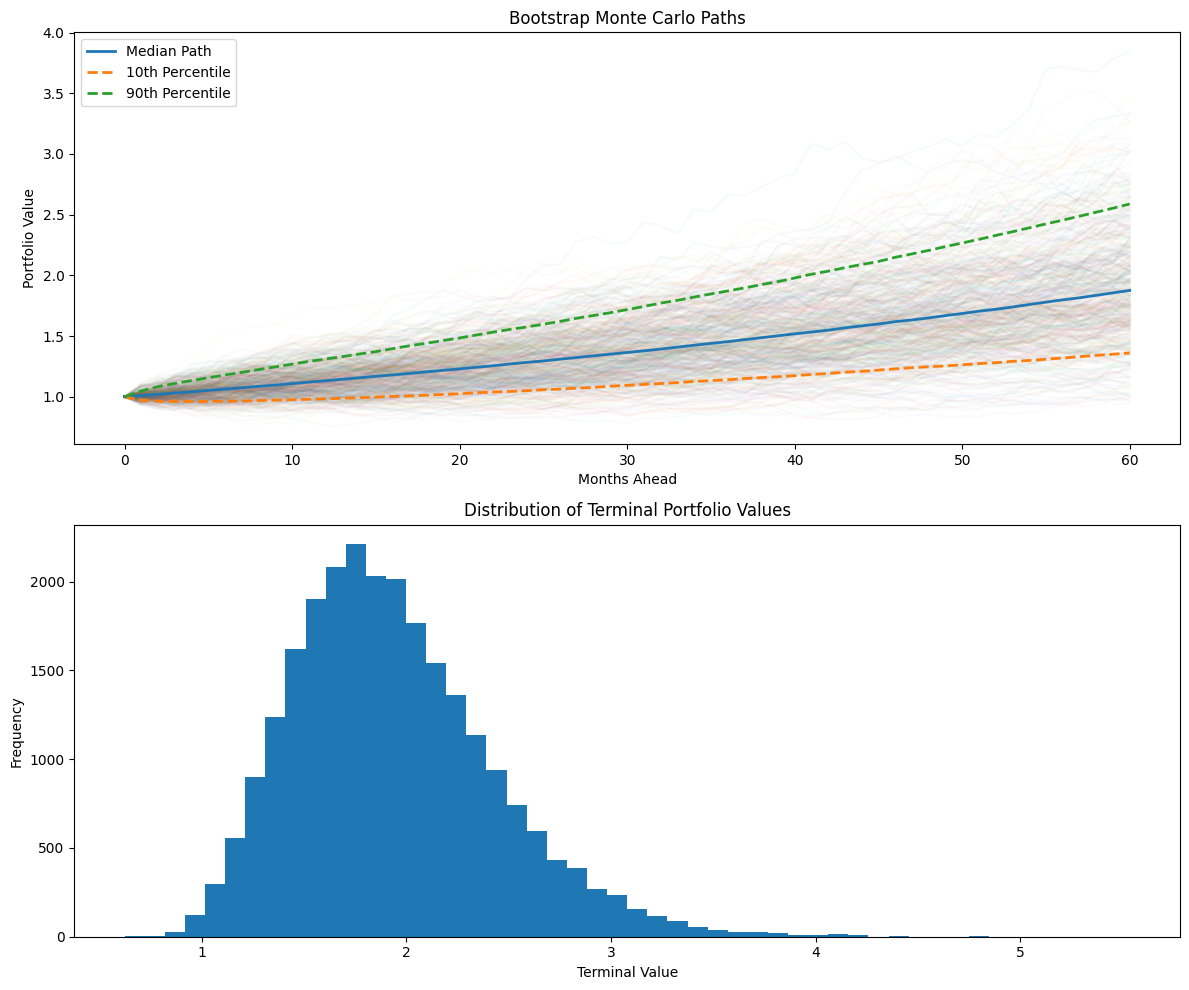

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# sample of faint paths
sample_idx = np.linspace(0, n_sims - 1, 500, dtype=int)
for j in sample_idx:
    axes[0].plot(sim_paths[:, j], alpha=0.03)

axes[0].plot(plot_df.index, plot_df["p50"], linewidth=2, label="Median Path")
axes[0].plot(plot_df.index, plot_df["p10"], linestyle="--", linewidth=2, label="10th Percentile")
axes[0].plot(plot_df.index, plot_df["p90"], linestyle="--", linewidth=2, label="90th Percentile")
axes[0].set_title("Bootstrap Monte Carlo Paths")
axes[0].set_xlabel("Months Ahead")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend()

axes[1].hist(terminal_values, bins=50)
axes[1].set_title("Distribution of Terminal Portfolio Values")
axes[1].set_xlabel("Terminal Value")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()